### R6 - NeuralNetwork and Deep Learning : Project 2 - The Street View House Numbers (SVHN) Dataset

### Project Objective:


The objective of the project is to learn how to implement a simple image classification pipeline based on the k-Nearest Neighbour and a deep neural network. The goals of this assignment are as follows:

● Understand the basic Image Classification pipeline and the data-driven approach (train/predict stages)

● Data fetching and understand the train/val/test splits.

● Implement and apply an optimal k-Nearest Neighbor (kNN) classifier (7.5 points)

● Print the classification metric report (2.5 points)

● Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

● Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points)

● Implement batch normalization for training the neural network (2.5 points)

● Understand the differences and trade-offs between traditional and NN classifiers with the help of classification metrics (5 points)

Data Set Reference: https://drive.google.com/file/d/1L2-WXzguhUsCArrFUc8EEkXcj33pahoS/view?usp=sharing 

In [0]:
# import numpy and pandas library
import numpy as np
import pandas as pd

In [0]:
from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [0]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [0]:
import h5py
import tensorflow as tf
import keras

Using TensorFlow backend.


In [0]:
import warnings 
warnings.filterwarnings('ignore')

### Questions :

In [0]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
h5FilePath="/content/drive/My Drive/GL-PGPAIML/Project/R6_NN-DL_Project2/SVHN_single_grey1.h5"

### 1. Read the dataset

In [0]:
#Read SVHN data from h5 file
svhn_h5f = h5py.File(h5FilePath,"r")

In [0]:
#Get Keys from h5py object
keys=svhn_h5f.keys()
for key in keys:
    print(key)

X_test
X_train
X_val
y_test
y_train
y_val


In [0]:
#Get Train, Test and Validation data along with Label
X_train=svhn_h5f['X_train'][:]
y_train=svhn_h5f['y_train'][:]

X_test=svhn_h5f['X_test'][:]
y_test=svhn_h5f['y_test'][:]

X_val=svhn_h5f['X_val'][:]
y_val=svhn_h5f['y_val'][:]

In [0]:
#Get Train Y label unique value
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#Get Test Y label unique value
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#Get Test Y label unique value
np.unique(y_val)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#Close h5 file
svhn_h5f.close()

In [0]:
print("Training Set",X_train.shape, y_train.shape )
print("Validation Set",X_val.shape, y_val.shape )
print("Test Set",X_test.shape, y_test.shape )

Training Set (42000, 32, 32) (42000,)
Validation Set (60000, 32, 32) (60000,)
Test Set (18000, 32, 32) (18000,)


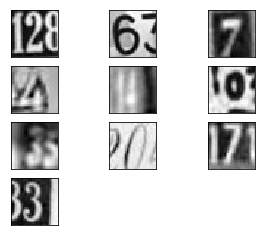

label for each of the above image:
 [2, 6, 7, 4, 4, 0, 3, 0, 7, 3]


In [0]:
# Visualize first 10 train data with label
labels = []

plt.figure(figsize=(5,5))
for i in range(10):
    plt.subplot(5,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))
    lbl=y_train[i]
    labels.append(lbl)
plt.show()
print("label for each of the above image:\n", labels)

### Implement and apply an optimal k-Nearest Neighbor (kNN) classifier (7.5 points)

In [0]:
from sklearn.neighbors import KNeighborsClassifier

In [0]:
# reshape dataset to 1D format
X_train_1d = X_train.reshape((X_train.shape[0], 32* 32))
X_test_1d = X_test.reshape((X_test.shape[0], 32* 32))
X_val_1d = X_val.reshape((X_val.shape[0], 32* 32))

In [0]:
X_train_1d[0]

array([33.0704, 30.2601, 26.852 , ..., 49.6682, 50.853 , 53.0377],
      dtype=float32)

In [0]:
print("1D Training Set",X_train_1d.shape, y_train.shape )
print("1D Validation Set",X_test_1d.shape, y_val.shape )
print("1D Test Set",X_val_1d.shape, y_test.shape )

1D Training Set (42000, 1024) (42000,)
1D Validation Set (18000, 1024) (60000,)
1D Test Set (60000, 1024) (18000,)


In [0]:
#K-Nearest Neighbour  Classifier Model

KNN = KNeighborsClassifier(n_neighbors= 2)

# Call Nearest Neighbour algorithm
KNN.fit(X_train_1d, y_train)


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=2, p=2,
                     weights='uniform')

In [0]:
#predict y value for test data using KNN
KNN_predict_y = KNN.predict(X_test_1d)


### Print the classification metric report (2.5 points)

In [0]:
from sklearn import metrics

In [0]:
cr=metrics.classification_report(y_test,KNN_predict_y)
print(cr)

              precision    recall  f1-score   support

           0       0.36      0.65      0.47      1814
           1       0.41      0.70      0.52      1828
           2       0.46      0.56      0.51      1803
           3       0.34      0.41      0.37      1719
           4       0.55      0.53      0.54      1812
           5       0.38      0.35      0.36      1768
           6       0.40      0.33      0.36      1832
           7       0.72      0.46      0.56      1808
           8       0.38      0.19      0.25      1812
           9       0.73      0.20      0.31      1804

    accuracy                           0.44     18000
   macro avg       0.47      0.44      0.42     18000
weighted avg       0.47      0.44      0.42     18000



### Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

#### Convert train, test and validation data labels to one hot vectors

In [0]:
num_classes = 10 # No. of unique Label in the dataset (From 1 to 10)
# Convert class vectors to binary class matrices
y_train_Encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_Encoded = keras.utils.to_categorical(y_test, num_classes)
y_val_Encoded = keras.utils.to_categorical(y_val, num_classes)

In [0]:
print(y_train_Encoded.shape)
print('First 5 examples now are: \n', y_train_Encoded[0:5])

(42000, 10)
First 5 examples now are: 
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [0]:
#Initialize Sequential model
nn_model1 = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 32x32 to 1024
nn_model1.add(tf.keras.layers.Reshape((1024,),input_shape=(32,32,)))
#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
nn_model1.add(tf.keras.layers.Dense(128, activation='relu'))
#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
nn_model1.add(tf.keras.layers.Dense(128, activation='relu'))
#Add Dense Layer which provides 10 Outputs after applying softmax
nn_model1.add(tf.keras.layers.Dense(10, activation='softmax'))



### Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points)



In [0]:
#Compile the model
nn_model1.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
# Fit the model1 with 100 epochs and batch size 32 for train and validation data
m1_history=nn_model1.fit(X_train, y_train_Encoded, 
          validation_data=(X_val, y_val_Encoded), 
          epochs=100,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/100
42000/42000 [==============================] - 6s 132us/sample - loss: 34492.9224 - acc: 0.1001 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 2/100
42000/42000 [==============================] - 5s 124us/sample - loss: 2.3027 - acc: 0.1008 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 3/100
42000/42000 [==============================] - 5s 125us/sample - loss: 2.3027 - acc: 0.1008 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 4/100
42000/42000 [==============================] - 5s 126us/sample - loss: 2.3027 - acc: 0.1006 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 5/100
42000/42000 [==============================] - 5s 126us/sample - loss: 2.3027 - acc: 0.1000 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 6/100
42000/42000 [==============================] - 5s 126us/sample - loss: 2.3027 - acc: 0.1019 - val_loss: 2.3026 - val_acc: 0.1000
Epoch 7/100
42000/42000 [==============================] - 6s 138us/sample - loss: 2.3027 - acc: 0.1

### Implement batch normalization for training the neural network (2.5 points)



In [0]:
#Initialize Sequential model
nn_model2 = tf.keras.models.Sequential()
#Reshape data from 2D to 1D -> 32x32 to 1024
nn_model2.add(tf.keras.layers.Reshape((1024,),input_shape=(32,32,)))
#Batch normalization of the data 
nn_model2.add(tf.keras.layers.BatchNormalization())
#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
nn_model2.add(tf.keras.layers.Dense(128, activation='relu'))
#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
nn_model2.add(tf.keras.layers.Dense(128, activation='relu'))
#Add Dense Layer which provides 10 Outputs after applying softmax
nn_model2.add(tf.keras.layers.Dense(10, activation='softmax'))


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
#Comile the model
nn_model2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
# Fit the model1 with 100 epochs and batch size 32 for train and validation data
m2_history=nn_model2.fit(X_train, y_train_Encoded, 
          validation_data=(X_val, y_val_Encoded), 
          epochs=100,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/100
42000/42000 [==============================] - 8s 185us/sample - loss: 1.6622 - acc: 0.4570 - val_loss: 1.1362 - val_acc: 0.6617
Epoch 2/100
42000/42000 [==============================] - 7s 172us/sample - loss: 1.1089 - acc: 0.6566 - val_loss: 0.9056 - val_acc: 0.7272
Epoch 3/100
42000/42000 [==============================] - 7s 171us/sample - loss: 0.9426 - acc: 0.7094 - val_loss: 0.8527 - val_acc: 0.7377
Epoch 4/100
42000/42000 [==============================] - 7s 174us/sample - loss: 0.8585 - acc: 0.7341 - val_loss: 0.7299 - val_acc: 0.7830
Epoch 5/100
42000/42000 [==============================] - 8s 187us/sample - loss: 0.8026 - acc: 0.7528 - val_loss: 0.8222 - val_acc: 0.7537
Epoch 6/100
42000/42000 [==============================] - 7s 177us/sample - loss: 0.7520 - acc: 0.7685 - val_loss: 0.6348 - val_acc: 0.8128
Epoch 7/100
42000/42000 [==============================] - 7s 168us/sample - loss: 0.7171 - acc: 0.7816 

##### Plot Model1 Fit output for Train & Validation Data

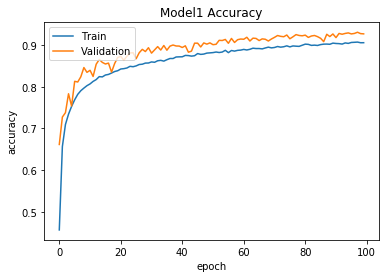

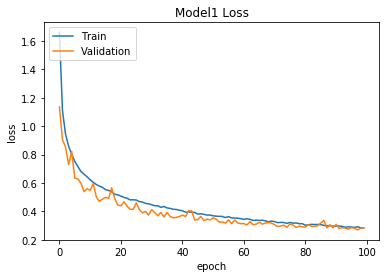

In [0]:
# summarize history for accuracy
plt.plot(m2_history.history['acc'])
plt.plot(m2_history.history['val_acc'])
plt.title('Model1 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m2_history.history['loss'])
plt.plot(m2_history.history['val_loss'])
plt.title('Model1 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [0]:
y_predict_nn_m2 = nn_model2.predict(X_test)

In [0]:
y_pred_NN_M2 = []
for val in y_predict_nn_m2:
    y_pred_NN_M2.append(np.argmax(val))

In [0]:
y_pred_NN_M2[0]

1

### Understand the differences and trade-offs between traditional and NN classifiers with the help of classification metrics (5 points)

In [0]:
cr_NN=metrics.classification_report(y_test,y_pred_NN_M2)
print(cr_NN)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1814
           1       0.86      0.86      0.86      1828
           2       0.86      0.89      0.88      1803
           3       0.80      0.82      0.81      1719
           4       0.88      0.87      0.87      1812
           5       0.81      0.87      0.84      1768
           6       0.88      0.81      0.85      1832
           7       0.87      0.90      0.89      1808
           8       0.85      0.80      0.83      1812
           9       0.85      0.84      0.85      1804

    accuracy                           0.86     18000
   macro avg       0.86      0.86      0.86     18000
weighted avg       0.86      0.86      0.86     18000



### Final Summary:


1.   In  given Street View House Numbers (SVHN) Dataset, we have below shape in the Train, Test and Validation dataset:

      Train Data : (42000, 32, 32)
      
      Test Data  :(60000, 32, 32)
      
      Validation : (18000, 32, 32)
2.   In the given data we have label value (output) from 1 to 10 in all the set.

3.  First model we buit with KNN image classifier and we got 44%.
4.  In our second model we have tried with Deep Neural Network (feedforward neural network, RELU activations and back propagation with SGD). In that we have got 10% accuracy.
5. Finally I tried with batch normalization in deep neural network which has given best accuracy 86%

### Additional : Model Building with CNN

### Reshape the data from 32x32 to 32x32x1 to match input dimensions in Conv2D layer in keras

In [0]:
# reshape dataset to have a single channel
X_train = X_train.reshape((X_train.shape[0], 32, 32, 1))
X_test = X_test.reshape((X_test.shape[0], 32, 32, 1))
X_val = X_val.reshape((X_val.shape[0], 32, 32, 1))

In [0]:
print("Training Set",X_train.shape )
print("Validation Set",X_val.shape )
print("Test Set",X_test.shape )

Training Set (42000, 32, 32, 1)
Validation Set (60000, 32, 32, 1)
Test Set (18000, 32, 32, 1)


#### CNN Model : 

 1. Let's build CNN model with 2 Conv layers having `32 3x3 filters` and '64 32x32' with `relu activations` 
 2. Then MaxPool with size 2 and 25% dropout Layer
 2. `flatten` before passing the feature map into 3 fully connected layers (or Dense Layers) having 2x128 dense layers ith 'Relu'
 3. 10 neurons with `relu` and `softmax` activations respectively. 
 4. Compile Model1 using `categorical_crossentropy` loss with `Adam` optimizer.
 5. And finally fit model 100 Epochs and 32 Batch Size.

In [0]:
#Initialize model1
model3 = tf.keras.models.Sequential()

In [0]:
model3.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 1)))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model3.add(tf.keras.layers.Dropout(0.25))
model3.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model3.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer - 128 Nurons with Relu
model3.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer/output layer - 10 Nurons with Softmax
model3.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
# compile model
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
# Fit the model1 with 100 epochs and batch size 32 for train and validation data
m3_history=model3.fit(X_train, y_train_Encoded, 
          validation_data=(X_val, y_val_Encoded), 
          epochs=30,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/30
42000/42000 [==============================] - 47s 1ms/sample - loss: 2.2378 - acc: 0.5613 - val_loss: 0.7972 - val_acc: 0.7683
Epoch 2/30
42000/42000 [==============================] - 48s 1ms/sample - loss: 0.8564 - acc: 0.7493 - val_loss: 0.6530 - val_acc: 0.8100
Epoch 3/30
42000/42000 [==============================] - 47s 1ms/sample - loss: 0.7592 - acc: 0.7787 - val_loss: 0.6005 - val_acc: 0.8266
Epoch 4/30
42000/42000 [==============================] - 48s 1ms/sample - loss: 0.7022 - acc: 0.7923 - val_loss: 0.5988 - val_acc: 0.8225
Epoch 5/30
42000/42000 [==============================] - 48s 1ms/sample - loss: 0.6481 - acc: 0.8075 - val_loss: 0.6175 - val_acc: 0.8199
Epoch 6/30
42000/42000 [==============================] - 48s 1ms/sample - loss: 0.6097 - acc: 0.8175 - val_loss: 0.5192 - val_acc: 0.8467
Epoch 7/30
42000/42000 [==============================] - 47s 1ms/sample - loss: 0.5790 - acc: 0.8252 - val_loss: 0.

### Plot CNN Model Fit output for Train & Validation Data

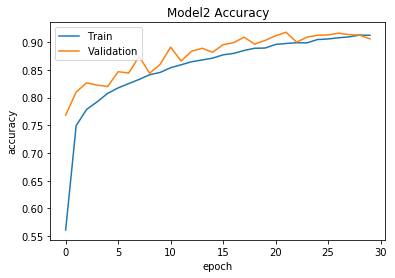

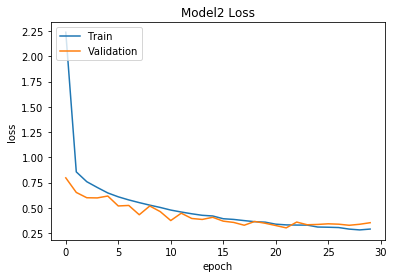

In [0]:
# summarize history for accuracy
plt.plot(m3_history.history['acc'])
plt.plot(m3_history.history['val_acc'])
plt.title('Model2 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m3_history.history['loss'])
plt.plot(m3_history.history['val_loss'])
plt.title('Model2 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate CNN Model with Test Data

In [0]:
model3_result=model3.evaluate(X_test,y_test,verbose=1)
print("Model3 - Test Data Accuracy : {0}".format(model3_result[1]*100))
print("Model3 - Test Data Loss : {0}".format(model3_result[0]))

18000/18000 [==============================] - 15s 853us/sample - loss: 0.3899 - acc: 0.8926
Model3 - Test Data Accuracy : 89.26110863685608
Model3 - Test Data Loss : 0.38988300482763183


In [0]:
y_predict_cnn_m3 = model3.predict(X_test)

In [0]:
y_pred_CNN_M3 = []
for val in y_predict_cnn_m3:
    y_pred_CNN_M3.append(np.argmax(val))

In [0]:
cr_CNN=metrics.classification_report(y_test,y_pred_CNN_M3)
print(cr_CNN)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1814
           1       0.90      0.82      0.86      1828
           2       0.85      0.89      0.87      1803
           3       0.74      0.85      0.79      1719
           4       0.87      0.89      0.88      1812
           5       0.91      0.78      0.84      1768
           6       0.90      0.78      0.83      1832
           7       0.86      0.89      0.88      1808
           8       0.77      0.84      0.80      1812
           9       0.84      0.85      0.84      1804

    accuracy                           0.85     18000
   macro avg       0.85      0.85      0.85     18000
weighted avg       0.85      0.85      0.85     18000



### CNN Model Summary:

In [0]:
model3.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 15, 15, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 15, 15, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 7200)              0         
_________________________________________________________________
dense_6 (Dense)              (None, 128)               921728    
_________________________________________________________________
dense_7 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_8 (Dense)              (None, 10)               